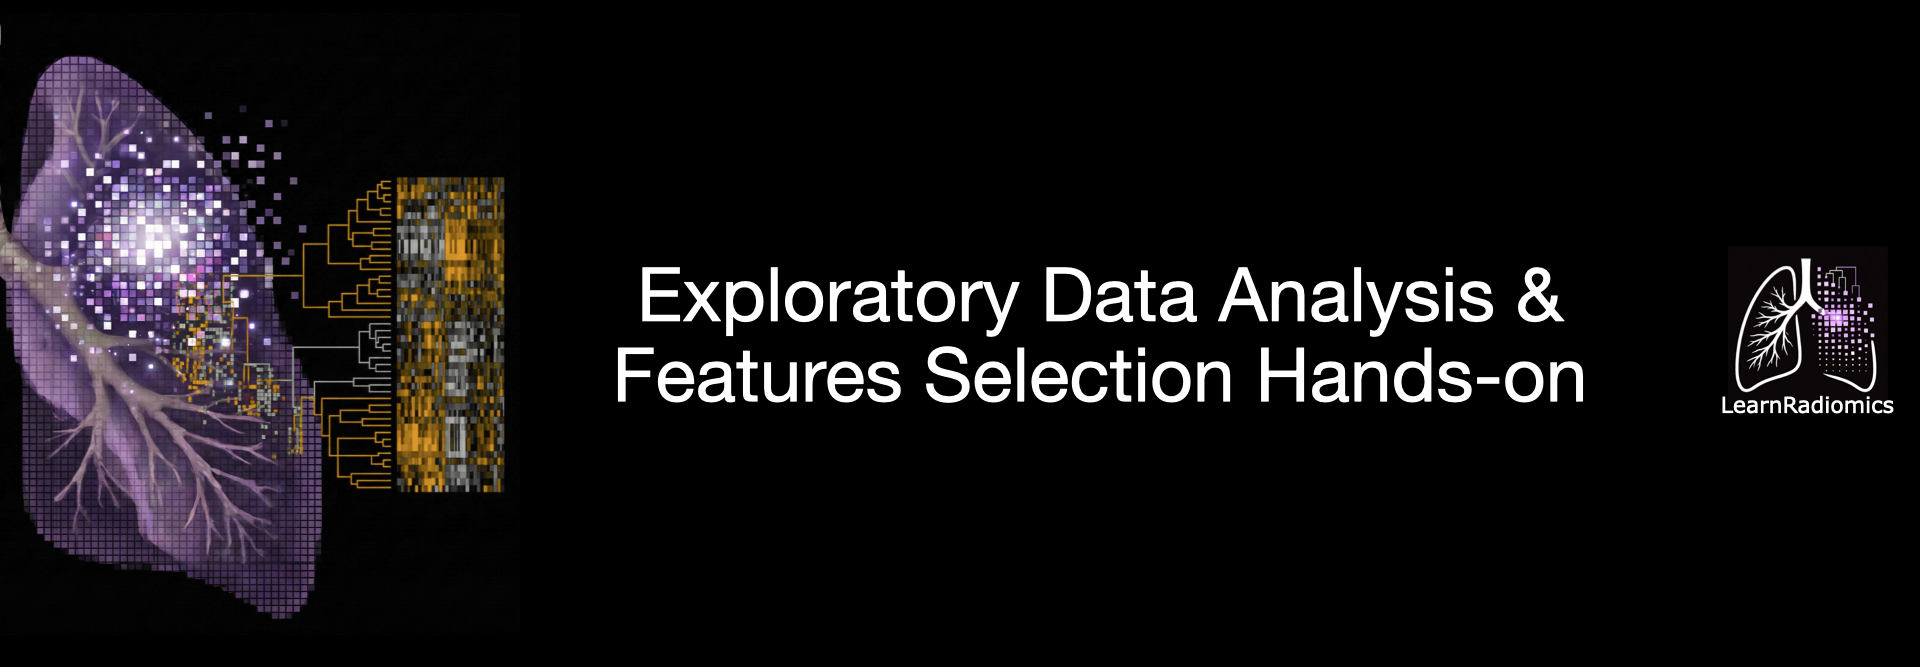

In [ ]:
## General libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from collections import Counter

## Data visualization
from plotnine import *
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

## Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Ridge, RidgeCV, LogisticRegressionCV

import sys
sys.modules['sklearn.externals.joblib'] = joblib

## Statistical tools libraries
from scipy import stats
from scipy.stats import mannwhitneyu, shapiro
import sklearn.metrics as mt
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
import statsmodels.api as sm
from sklearn.metrics import accuracy_score as acc
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from mlxtend.feature_selection import SequentialFeatureSelector as sfs
from scipy.stats import chi2_contingency
import itertools

## Medición de timpo y flujo de trabajo
import time
from tqdm import trange

## Sistema
import warnings
warnings.filterwarnings("ignore", category = FutureWarning)

from IPython.display import clear_output

## Exploratory analysis

* NSCLC dataset with radiomic features extracted using filters.
* Target: prediction of EGFR mutation

In [ ]:
url = 'https://raw.githubusercontent.com/learnradiomics/data_wrangling/main/data_radiomics_selected.xlsx'

df = pd.read_excel(url)

print(f'Number of patients: {df.shape[0]}')
print(f'Number of variables: {df.shape[1]}')

In [ ]:
## Included clinical features
df.columns[0:13]

In [ ]:
for i in range(len(df.columns)):
    print(i, ':', df.columns[i])

In [ ]:
## Gender
print("Percentage of women:",
      Counter(df['Gender_Female'])[1]/(Counter(df['Gender_Female'])[0] + Counter(df['Gender_Female'])[1]))

In [ ]:
### Age
print(f"Mean age: {df['Age_at_Histological_Diagnosis'].mean()}")
print(f"Median age: {df['Age_at_Histological_Diagnosis'].median()}")
print(f"Age range: ({df['Age_at_Histological_Diagnosis'].min()} - {df['Age_at_Histological_Diagnosis'].max()})")

In [ ]:
(

    ggplot(df) +
    aes(x='Age_at_Histological_Diagnosis') +
    geom_histogram(fill='mediumorchid', color='darkgray', alpha=0.7, bins=40)+
    theme_bw()+
    labs(title='Age distribution', x='Age')
)

In [ ]:
## Variable target
Counter(df['EGFR_mutation_status_Mutant'])

In [ ]:
### Is mutation prevalence different between men and women?
female_mutant = df[df.Gender_Female == 1]['EGFR_mutation_status_Mutant']
male_mutant = df[df.Gender_Female == 0]['EGFR_mutation_status_Mutant']

print("Mutation count in women: ", Counter(female_mutant))
print("Mutation count in men: ", Counter(male_mutant))


In [ ]:
### Hypothesis test
### H0: mutation prevalence in men = mutation prevalence in women
### H1: mutation prevalence in men < mutation prevalence in women
### Alpha= 0.05

### Statistical test for categorical variables:

# Example: association between Sex and Outcome
table = pd.crosstab(df['Gender_Female'], df['EGFR_mutation_status_Mutant'])

chi2_stat, p_value, dof, expected = chi2_contingency(table)

print("Contingency table:")
print(table)
print("\nChi2:", chi2_stat)
print("p-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:")
print(expected)


In [ ]:
### Age and EGFR mutation

age_mutant = df[df['EGFR_mutation_status_Mutant'] == 1]['Age_at_Histological_Diagnosis']
age_wildtype = df[df['EGFR_mutation_status_Mutant'] == 0]['Age_at_Histological_Diagnosis']

print("Median age in patients with EGFR mutation: ", age_mutant.median())
print("Median age in patients without EGFR mutation: ", age_wildtype.median())

In [ ]:
### Are patients with EGFR mutation younger than those without EGFR mutation?
### H0: age in EGFR-mutated patients = age in non-mutated EGFR patients
### H1: age in EGFR-mutated patients != age in non-mutated EGFR patients
### Alpha= 0.05

U1, p = mannwhitneyu(age_mutant,age_wildtype, alternative='two-sided')
print(f"U statistic: {U1}")
print(f"p-value: {p}")

In [ ]:
# One-hot ethnicity columns
ethnicity_columns = [
    'Ethnicity_Caucasian',
    'Ethnicity_Native_Hawaiian/Pacific_Islander',
    'Ethnicity_African_American',
    'Ethnicity_Asian',
    'Ethnicity_Hispanic/Latino'
]

# Sum each column to obtain the absolute frequency
counts = df[ethnicity_columns].sum().reset_index()
counts.columns = ['Ethnicity', 'Count']

# Clean names for better display in the plot
counts['Ethnicity'] = counts['Ethnicity'].str.replace('Ethnicity_', '', regex=False)

# Bar plot
plot = (
    ggplot(counts, aes(x='Ethnicity', y='Count'))
    + geom_col(fill='mediumorchid', alpha=0.7, color='darkgray')
    + theme_bw()
    + labs(
        title='Ethnicity',
        x='Ethnicity',
        y='Count'
    )
    + theme(
        axis_text_x=element_text(rotation=45, ha='right'),
        figure_size=(10, 7)
    )+

        scale_y_continuous(breaks=list(range(0,135,10)))
)

plot

In [ ]:
### Does EGFR mutation prevalence differ by ethnicity?
### First, a binary question: difference between Caucasian versus non-Caucasian patients

### H0: EGFR mutation prevalence in Caucasian patients = prevalence in non-Caucasian patients.
### H1: EGFR mutation prevalence in Caucasian patients != prevalence in non-Caucasian patients.
### Alpha= 0.05

table2 = pd.crosstab(df['Ethnicity_Caucasian'], df['EGFR_mutation_status_Mutant'])

chi2_stat, p_value, dof, expected = chi2_contingency(table2)

print("Contingency table:")
print(table2)
print("\nChi2:", chi2_stat)
print("p-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:")
print(expected)

In [ ]:
### And in the case of Asian patients?

table3 = pd.crosstab(df['Ethnicity_Asian'], df['EGFR_mutation_status_Mutant'])

chi2_stat, p_value, dof, expected = chi2_contingency(table3)

print("Contingency table:")
print(table3)
print("\nChi2:", chi2_stat)
print("p-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:")
print(expected)

In [ ]:
### Tabaco
table4 = pd.crosstab(df['Smoking_status_Nonsmoker'], df['EGFR_mutation_status_Mutant'])

chi2_stat, p_value, dof, expected = chi2_contingency(table4)

print("Contingency table:")
print(table4)
print("\nChi2:", chi2_stat)
print("p-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:")
print(expected)

In [ ]:
### Weight

(
ggplot(df)+
    aes(x='EGFR_mutation_status_Mutant', y='Weight_(lbs)', fill='factor(EGFR_mutation_status_Mutant)')+
    geom_boxplot(alpha=0.6, show_legend=False)+
    theme_bw()

)

In [ ]:
(
    ggplot(df) +
    aes(x='Weight_(lbs)')+
    geom_histogram(fill='mediumorchid', color='black', alpha=0.6, bins=40) +
    theme_classic()
)

In [ ]:
### Normally distributed data?
from scipy.stats import shapiro

stat, p_value = shapiro(df['Weight_(lbs)'])

print("W statistic =", stat)
print("p-value =", p_value)

if p_value > 0.05:
    print("Normality is not rejected")
else:
    print("Normality is rejected")

In [ ]:
### Non-parametric test:

weight_mutant = df[df['EGFR_mutation_status_Mutant'] == 1]['Weight_(lbs)']
weight_wildtype = df[df['EGFR_mutation_status_Mutant'] == 0]['Weight_(lbs)']

print("Mean weight in EGFR-mutated patients:", weight_mutant.mean())
print("Mean weight in EGFR wild-type patients:", weight_wildtype.mean())

U1, p = mannwhitneyu(weight_mutant,weight_wildtype, alternative='two-sided')
print(f"U statistic: {U1}")
print(f"p-value: {p}")

### Radiomics features

In [ ]:
radiomics_class = []
features_class_dictionay = dict()

for var in df.columns[13:]:
    feature_type = var.split('_')[1]

    if feature_type not in features_class_dictionay:
        features_class_dictionay[feature_type] = []

    features_class_dictionay[feature_type].append(var)
    radiomics_class.append(feature_type)

Counter(radiomics_class)

In [ ]:
matrix = df.loc[:,features_class_dictionay['firstorder']].copy()
matrix

In [ ]:

# Select numerical variables
corr_df = df.loc[:, features_class_dictionay['shape']].select_dtypes(include=np.number)

# Compute correlation matrix
corr_matrix = corr_df.corr()

# Plot
fig, ax = plt.subplots(figsize=(16,16))

im = ax.imshow(corr_matrix, cmap='PuOr', vmin=-1, vmax=1)

# Ticks and labels
ax.set_xticks(range(corr_matrix.shape[1]))
ax.set_yticks(range(corr_matrix.shape[0]))
ax.set_xticklabels(corr_matrix.columns, fontsize=12, rotation=30, ha='right')
ax.set_yticklabels(corr_matrix.columns, fontsize=14)

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=14)

ax.set_title('Correlation Matrix', fontsize=18)

plt.tight_layout()
plt.show()

## Models univariados

In [ ]:
df.columns[0:30]

In [ ]:
df_xy = df.drop(columns=['Histology_Adenocarcinoma', 'Histology_Squamous_cell_carcinoma',
       'Histology_NSCLC_NOS_(not_otherwise_specified)','EGFR_mutation_status_Mutant'])

df_xy.insert(loc=0,
            column='EGFR_mutation_status_Mutant',
            value=df.EGFR_mutation_status_Mutant)

df_xy.head(3)

In [ ]:
import statsmodels.api as sm

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import roc_auc_score


def univariate_logistic_repeated_auc_scaled(
    df,
    target_col,
    feature_cols,
    n_splits=30,
    test_size=0.30,
    random_state=42,
    scaler_method='standard',
    min_train_n=20,
    min_test_n=10,
    dropna=True,
    verbose=False
):
    """
    Iterative evaluation of univariate logistic regression for multiple variables
    using StratifiedShuffleSplit, scaling fitted only on the training set, and AUC on the test set.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with target and predictors.
    target_col : str
        Name of the binary target variable (0/1).
    feature_cols : list
        List of numerical predictor variables to evaluate.
    n_splits : int
        Number of repeated splits.
    test_size : float
        Proportion of the test set.
    random_state : int
        Seed for reproducibility.
    scaler_method : str
        'standard', 'minmax', or 'robust'.
    min_train_n : int
        Minimum number of observations required in the training set.
    min_test_n : int
        Minimum number of observations required in the test set.
    dropna : bool
        If True, removes NA values in each split and for each variable.
    verbose : bool
        If True, prints errors.

    Returns
    -------
    results_df : pd.DataFrame
        Summary per variable.
    """

    # Scaler selection
    if scaler_method == 'standard':
        scaler_class = StandardScaler
    elif scaler_method == 'minmax':
        scaler_class = MinMaxScaler
    elif scaler_method == 'robust':
        scaler_class = RobustScaler
    else:
        raise ValueError("scaler_method must be 'standard', 'minmax', or 'robust'")

    y_global = df[target_col].values

    splitter = StratifiedShuffleSplit(
        n_splits=n_splits,
        test_size=test_size,
        random_state=random_state
    )

    results = []

    for feature in feature_cols:
        aucs = []
        betas = []
        ors = []
        pvals = []
        ci_lows = []
        ci_highs = []

        n_train_list = []
        n_test_list = []

        failed_splits = 0

        for split_number, (train_idx, test_idx) in enumerate(splitter.split(df, y_global), start=1):
            try:
                data_train = df.iloc[train_idx][[target_col, feature]].copy()
                data_test = df.iloc[test_idx][[target_col, feature]].copy()

                if dropna:
                    data_train = data_train.dropna()
                    data_test = data_test.dropna()

                n_train = len(data_train)
                n_test = len(data_test)

                n_train_list.append(n_train)
                n_test_list.append(n_test)

                # Minimum checks
                if n_train < min_train_n or n_test < min_test_n:
                    failed_splits += 1
                    continue

                # Verify binary target in both splits
                if data_train[target_col].nunique() != 2:
                    failed_splits += 1
                    continue

                if data_test[target_col].nunique() != 2:
                    failed_splits += 1
                    continue

                # Verify predictor variability
                if data_train[feature].nunique() < 2:
                    failed_splits += 1
                    continue

                # Scaling fitted only on the training set
                scaler = scaler_class()

                X_train_raw = data_train[[feature]].astype(float)
                X_test_raw = data_test[[feature]].astype(float)

                X_train_scaled = scaler.fit_transform(X_train_raw)
                X_test_scaled = scaler.transform(X_test_raw)

                X_train_scaled = pd.DataFrame(
                    X_train_scaled,
                    columns=[feature],
                    index=data_train.index
                )
                X_test_scaled = pd.DataFrame(
                    X_test_scaled,
                    columns=[feature],
                    index=data_test.index
                )

                y_train = data_train[target_col]
                y_test = data_test[target_col]

                # Logistic fitting
                X_train_model = sm.add_constant(X_train_scaled)
                fit = sm.Logit(y_train, X_train_model).fit(method='lbfgs',
                                                           maxiter=200,disp=0,warn_convergence=False)


                # Verify actual convergence
                if not getattr(fit, 'mle_retvals', {}).get('converged', True):
                    raise RuntimeError('model_not_converged')


                beta = fit.params[feature]
                p_value = fit.pvalues[feature]
                ci_low, ci_high = fit.conf_int().loc[feature]

                # Prediction on the test set
                X_test_model = sm.add_constant(X_test_scaled, has_constant='add')
                y_prob_test = fit.predict(X_test_model)
                auc_test = roc_auc_score(y_test, y_prob_test)

                aucs.append(auc_test)
                betas.append(beta)
                ors.append(np.exp(beta))
                pvals.append(p_value)
                ci_lows.append(np.exp(ci_low))
                ci_highs.append(np.exp(ci_high))

            except Exception as e:
                failed_splits += 1
                if verbose:
                    print(f'Error in feature {feature}, split {split_number}: {e}')
                continue

        successful_splits = len(aucs)

        if successful_splits == 0:
            results.append({
                'feature': feature,
                'mean_AUC_test': np.nan,
                'std_AUC_test': np.nan,
                'median_AUC_test': np.nan,
                'mean_beta_train': np.nan,
                'mean_OR_train': np.nan,
                'median_p_value_train': np.nan,
                'mean_CI95_low_train': np.nan,
                'mean_CI95_high_train': np.nan,
                'mean_n_train': np.nan if len(n_train_list) == 0 else np.mean(n_train_list),
                'mean_n_test': np.nan if len(n_test_list) == 0 else np.mean(n_test_list),
                'successful_splits': 0,
                'failed_splits': failed_splits,
                'scaler': scaler_method,
                'status': 'no_valid_fit'
            })
        else:
            results.append({
                'feature': feature,
                'mean_AUC_test': np.mean(aucs),
                'std_AUC_test': np.std(aucs),
                'median_AUC_test': np.median(aucs),
                'mean_beta_train': np.mean(betas),
                'mean_OR_train': np.mean(ors),
                'median_p_value_train': np.median(pvals),
                'mean_CI95_low_train': np.mean(ci_lows),
                'mean_CI95_high_train': np.mean(ci_highs),
                'mean_n_train': np.mean(n_train_list) if len(n_train_list) > 0 else np.nan,
                'mean_n_test': np.mean(n_test_list) if len(n_test_list) > 0 else np.nan,
                'successful_splits': successful_splits,
                'failed_splits': failed_splits,
                'scaler': scaler_method,
                'status': 'ok'
            })

    results_df = pd.DataFrame(results).sort_values(
        by=['mean_AUC_test', 'median_p_value_train'],
        ascending=[False, True],
        na_position='last'
    ).reset_index(drop=True)

    return results_df

In [ ]:
target_col = 'EGFR_mutation_status_Mutant'

results_repeated_scaled = univariate_logistic_repeated_auc_scaled(
    df=df_xy,
    target_col=target_col,
    feature_cols=df_xy.columns[1:],
    n_splits=100, ## Repeticiones
    test_size=0.30,
    random_state=42,
    scaler_method='standard',   # 'standard', 'minmax' o 'robust'
    min_train_n=20,
    min_test_n=10,
    dropna=True,
    verbose=False
)

results_repeated_scaled.head(20)

In [ ]:
threshold = .05

features_univariate_filter = results_repeated_scaled[results_repeated_scaled.median_p_value_train < threshold].feature.to_list()

print("Number of significant variables:", results_repeated_scaled[results_repeated_scaled.median_p_value_train < threshold].shape[0])
print("Variables:\n\n",features_univariate_filter)


In [ ]:
results_repeated_scaled.sort_values(by=["mean_AUC_test"], ascending=False).head(30)

### L1-regularized regression (Lasso)

In [ ]:

from sklearn.linear_model import Lasso

scaler = StandardScaler()
XRadiomicsScale = scaler.fit_transform(df_xy.iloc[:,1:])

alphas = np.linspace(0.001,1000,500)
lasso = Lasso(max_iter=10000)
coefs = []


for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(XRadiomicsScale, df_xy.iloc[:,0])
    coefs.append(lasso.coef_)

plt.figure(figsize=(14, 6))

ax = plt.gca()

ax.plot(alphas, coefs, alpha=0.7)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('Standardized coefficients')
plt.title('Lasso coefficients versus alpha parameter')
#plt.savefig('Seleccion variables parametro alpha.png', dpi=300)
plt.show()

In [ ]:

X = df_xy.iloc[:, 1:]
y = df_xy.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=0,
    stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logit_l1_cv', LogisticRegressionCV(
        Cs=np.logspace(-4, 4, 10),
        cv=cv,
        penalty='l1',
        solver='liblinear',
        scoring='roc_auc',
        random_state=0,
        max_iter=2000
    ))
])

pipeline.fit(X_train, y_train)

model = pipeline.named_steps['logit_l1_cv']

best_C = model.C_[0] if np.ndim(model.C_) else model.C_
print(f'Best C found: {best_C}')

positive_class = model.classes_[1]
mean_scores = model.scores_[positive_class].mean(axis=0)

plt.figure(figsize=(10, 6))
plt.semilogx(model.Cs_, mean_scores, marker='o')
plt.axvline(best_C, linestyle='--', color='red', label=f'Best C: {best_C}')
plt.xlabel('C')
plt.ylabel('Mean CV ROC-AUC')
plt.title('Optimization of C in logistic regression with L1 regularization')
plt.legend()
plt.grid(True)
plt.show()

coef = model.coef_[0]
selected_features_lasso = X_train.columns[coef != 0]

print("Number of selected variables:", len(selected_features_lasso))
print("Selected features:")
print(selected_features_lasso.tolist())

y_prob_test = pipeline.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, y_prob_test)
print(f'Test AUC: {auc_test:.3f}')

### Recursive feature elimination

In [ ]:
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

# -----------------------------
# data
# -----------------------------
X = df_xy.iloc[:, 1:].copy()
y = df_xy.iloc[:, 0].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# -----------------------------
# base model
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# -----------------------------
# Sequential Forward Selection
# -----------------------------
sfs_forward = SequentialFeatureSelector(
    estimator=rf,
    n_features_to_select=10,   # you can change it to a fixed number, e.g., 10
    direction='forward',
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

sfs_forward.fit(X_train, y_train)

selected_mask = sfs_forward.get_support()
selected_features_sfs = X_train.columns[selected_mask].tolist()

print("Selected variables (forward):")
print(selected_features_sfs)

# -----------------------------
# final model with selected variables
# -----------------------------
rf_final = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_final.fit(X_train[selected_features_sfs], y_train)

y_prob_test = rf_final.predict_proba(X_test[selected_features_sfs])[:, 1]
auc_test = roc_auc_score(y_test, y_prob_test)

print(f"Test AUC: {auc_test:.3f}")

### First simple model with selected variables

In [ ]:
## Selected variable sets:

## 1. Filter method:
print(f"Variables selected by filter method:{features_univariate_filter}. \n")

## 2. Lasso:
print(f"Variables selected by L1 regression (Lasso):{selected_features_lasso}. \n")

### 3. SFS
print(f"Variables selected by Recursive Feature Elimination:{selected_features_sfs}. \n")

In [ ]:
### Function to normalize the dataframe

def scale_dataframe(df, columns=None):
    df_scaled = df.copy()

    if columns is None:
        columns = df_scaled.select_dtypes(include='number').columns.tolist()

    scaler = StandardScaler()
    df_scaled[columns] = scaler.fit_transform(df_scaled[columns])

    return df_scaled, scaler

In [ ]:
### Value scaling
df_scaled, scaler = scale_dataframe(df_xy.loc[:, selected_features_lasso],
                                      columns=selected_features_lasso)

X_train, X_test, y_train, y_test = train_test_split(df_scaled, df_xy.iloc[:, 0],
                                                    test_size=0.3, random_state=45)

model = LogisticRegression(
    penalty='l2',
    C=0.4,
    solver='lbfgs',
    max_iter=1000
)

model.fit(X_train, y_train)
y_prob_test = model.predict_proba(X_test)[:, 1]
pred_test_bin = np.where(y_prob_test>0.5,1,0)

auc_test = roc_auc_score(y_test, y_prob_test)
print(classification_report(y_test, pred_test_bin))
print(f"AUC: {round(auc_test,3)} ")